In [ ]:
# Instalamos la librería
!pip install thermo

In [ ]:
# Importamos las libreías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from IPython.display import display, Markdown
from thermo import Chemical

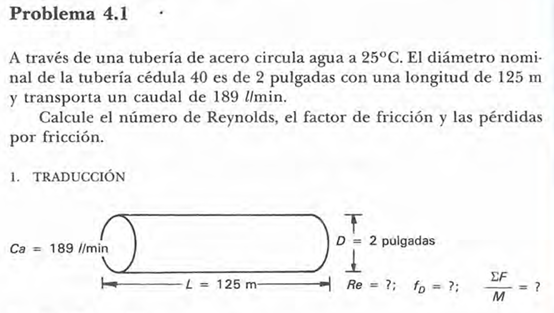 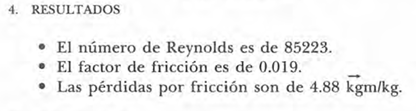

In [ ]:
# PROBLEMA 4.1 VALIENTE
# Paso 1: Definimos nuestras variables
Ca = 189 / 60000    # m^3/s
D = 5.25 / 100      # m
L = 125             # m

# Propiedades del agua a 25 °C y 1 atm
agua = Chemical("water", T=298.15, P=101325)
rho = agua.rhol     # kg/m^3
mu = agua.mul       # Pa*s
g = 9.81            # m/s^2
e_D = 0.0009        # e/D para acero comercial

# Paso 2: Definimos el sistema de ecuaciones no lineales
def sistema(vars):
    Re, FM, fF, v, fD = vars

    if Re <= 0 or fF <= 0 or fD <= 0 or v <= 0:
        return [1e6, 1e6, 1e6, 1e6, 1e6]

    eq1 = v - 4*Ca/(np.pi*D**2)
    eq2 = Re - rho*D*v/mu
    eq3 = FM - fD*(v**2*L)/(2*g*D)
    eq4 = (1/np.sqrt(fF)) - (4.06*np.log10(1/e_D) + 2.16)
    eq5 = fD - 4*fF

    return [eq1, eq2, eq3, eq4, eq5]

# Suposición inicial
guess = [1e5, 1, 0.005, 1.5, 0.02]

# Paso 3: Resolver el sistema
sol = fsolve(sistema, guess)
Re, FM, fF, v, fD = sol

# Paso 4: Tabla de resultados
tabla_resumen = pd.DataFrame({
    "Variable": ["Re", "FM", "v", "fD"],
    "Valor": [Re, FM, v, fD],
    "Unidad": ["adimensional", "m", "m/s", "adimensional"]
})

tabla_resumen["Valor"] = tabla_resumen["Valor"].round(5)
display(tabla_resumen.style.hide(axis="index"))

Variable,Valor,Unidad
Re,85565.053630,adimensional
FM,4.871210,m
v,1.455130,m/s
fD,0.018960,adimensional


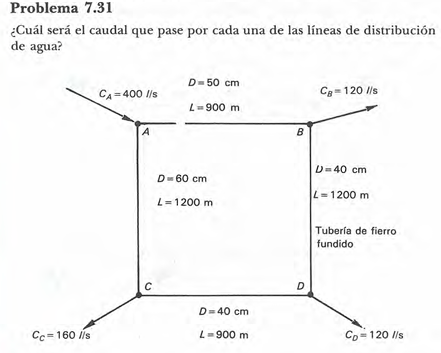 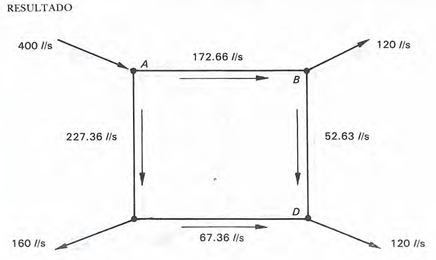

In [ ]:
# PROBLEMA DE RED DE TUBERIAS (VALIENTE 7.31)
# Paso 1: Definimos nuestras variables
# Propiedades del agua a 25 °C y 1 atm
agua = Chemical("water", T=298.15, P=101325)
rho = agua.rhol      # kg/m^3
mu = agua.mul        # Pa*s
ViscRel = mu / rho   # m^2/s

# Diámetros
D1 = 50 / 100                 # m
D2 = 60 / 100                 # m
D3 = 40 / 100                 # m
D4 = 40 / 100                 # m

# Longitudes
L1 = 900                      # m
L2 = 1200                     # m
L3 = 1200                     # m
L4 = 900                      # m

# Caudales conocidos
QV6 = 400 / 1000              # m^3/s
QV8 = 120 / 1000              # m^3/s
QV7 = 160 / 1000              # m^3/s
QV5 = 120 / 1000              # m^3/s

# Rugosidad relativa e/D
# e = 0.00085 ft para cast iron
e_abs = 0.00085 / 3.2808      # m

Var1 = e_abs / D1
Var2 = e_abs / D2
Var3 = e_abs / D3
Var4 = e_abs / D4

# Áreas
A1 = np.pi * D1**2 / 4
A2 = np.pi * D2**2 / 4
A3 = np.pi * D3**2 / 4
A4 = np.pi * D4**2 / 4

# Paso 2: Definimos el sistema de ecuaciones no lineales
def sistema(vars):
    DeltaP1, DeltaP2, DeltaP3, DeltaP4, \
    Re1, Re2, Re3, Re4, \
    Ff1, Ff2, Ff3, Ff4, \
    QV1, QV2, QV3, QV4 = vars

    # Evitar raíces/logaritmos inválidos
    if min(Re1, Re2, Re3, Re4, Ff1, Ff2, Ff3, Ff4, QV1, QV2, QV3, QV4) <= 0:
        return [1e6]*16

    # Velocidades
    V1 = QV1 / A1
    V2 = QV2 / A2
    V3 = QV3 / A3
    V4 = QV4 / A4

    # Ecuaciones de caída de presión
    eq1 = -DeltaP1 + 2 * L1 * Ff1 * V1**2 * rho / D1
    eq2 = -DeltaP2 + 2 * L2 * Ff2 * V2**2 * rho / D2
    eq3 = -DeltaP3 + 2 * L3 * Ff3 * V3**2 * rho / D3
    eq4 = -DeltaP4 + 2 * L4 * Ff4 * V4**2 * rho / D4

    # Reynolds
    eq5 = Re1 - V1 * D1 / ViscRel
    eq6 = Re2 - V2 * D2 / ViscRel
    eq7 = Re3 - V3 * D3 / ViscRel
    eq8 = Re4 - V4 * D4 / ViscRel

    # Factor de fricción (forma tipo Haaland para Fanning)
    eq9  = 1/np.sqrt(Ff1) + 3.6*np.log10(6.9/Re1 + (Var1/3.7)**1.111)
    eq10 = 1/np.sqrt(Ff2) + 3.6*np.log10(6.9/Re2 + (Var2/3.7)**1.111)
    eq11 = 1/np.sqrt(Ff3) + 3.6*np.log10(6.9/Re3 + (Var3/3.7)**1.111)
    eq12 = 1/np.sqrt(Ff4) + 3.6*np.log10(6.9/Re4 + (Var4/3.7)**1.111)

    # Balance de caudales
    eq13 = -QV5 + QV3 + QV4
    eq14 = -QV6 + QV1 + QV2
    eq15 = -QV1 + QV8 + QV3

    # Balance de presión en lazo
    eq16 = -DeltaP1 - DeltaP3 + DeltaP2 + DeltaP4

    return [eq1, eq2, eq3, eq4,
            eq5, eq6, eq7, eq8,
            eq9, eq10, eq11, eq12,
            eq13, eq14, eq15, eq16]

# Suposiciones iniciales
guess = [
    330, 340, 230, 240,        # DeltaP1..DeltaP4
    2e6, 2e6, 2e6, 2e6,        # Re1..Re4
    0.001, 0.0031, 0.001, 0.0031,  # Ff1..Ff4
    0.17266, 0.22736, 0.05263, 0.067361  # QV1..QV4
]

# Paso 3: Resolver el sistema
sol = fsolve(sistema, guess)

DeltaP1, DeltaP2, DeltaP3, DeltaP4, \
Re1, Re2, Re3, Re4, \
Ff1, Ff2, Ff3, Ff4, \
QV1, QV2, QV3, QV4 = sol

# Velocidades finales
V1 = QV1 / A1
V2 = QV2 / A2
V3 = QV3 / A3
V4 = QV4 / A4


# Paso 4: Tabla de resultados
tabla = pd.DataFrame({
    "Variable": ["QV1", "QV2", "QV3", "QV4"],
    "Valor": [QV1*1000, QV2*1000, QV3*1000, QV4*1000],
    "Unidad": ["L/s", "L/s", "L/s", "L/s"]
})

tabla["Valor"] = tabla["Valor"].apply(lambda x: f"{x:.6f}")
display(tabla.style.hide(axis="index"))

Variable,Valor,Unidad
QV1,172.267440,L/s
QV2,227.732560,L/s
QV3,52.267440,L/s
QV4,67.732560,L/s


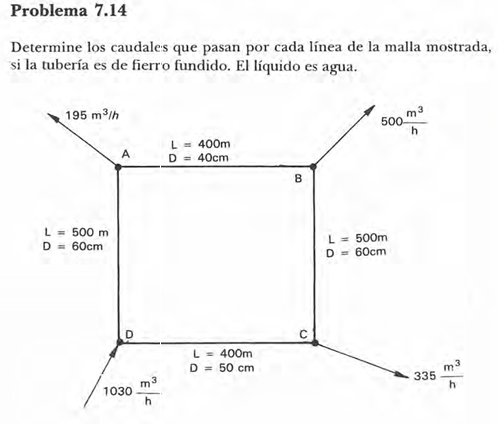 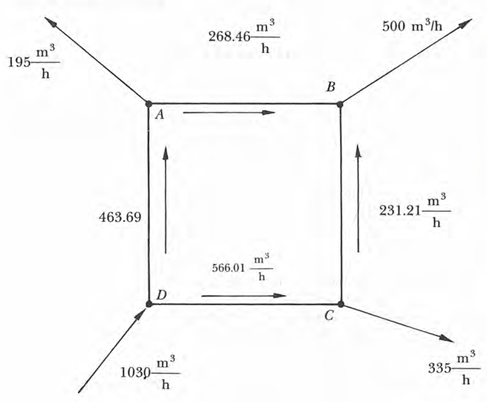

In [ ]:
# PROBLEMA DE RED DE TUBERÍAS (VALIENTE 7.14)
# Paso 1: Definimos nuestras variables
# Propiedades del agua a 25 °C y 1 atm
agua = Chemical("water", T=298.15, P=101325)
rho = agua.rhol      # kg/m^3
mu = agua.mul        # Pa*s
ViscRel = mu / rho   # m^2/s

# Diámetros de las tuberías
D1 = 60 / 100          # m
D2 = 40 / 100          # m
D3 = 50 / 100          # m
D4 = 60 / 100          # m

# Flujos dados
QV6 = 1030 / 3600      # m^3/s
QV8 = 195 / 3600       # m^3/s
QV7 = 335 / 3600       # m^3/s
QV5 = 500 / 3600       # m^3/s

# Rugosidad absoluta e = 0.00085 ft -> m
# Material: Cast iron (hierro fundido)
e = 0.00085 / 3.2808   # m

# Rugosidades relativas
Var1 = e / D1
Var2 = e / D2
Var3 = e / D3
Var4 = e / D4

# Longitudes
L1 = 500.0             # m
L2 = 400.0             # m
L3 = 400.0             # m
L4 = 500.0             # m

# Áreas de tubería
A1 = np.pi * D1**2 / 4.0
A2 = np.pi * D2**2 / 4.0
A3 = np.pi * D3**2 / 4.0
A4 = np.pi * D4**2 / 4.0

# Paso 2: Definimos el sistema de ecuaciones no lineales
def sistema(vars):
    DeltaP1, DeltaP2, DeltaP3, DeltaP4, \
    Re1, Re2, Re3, Re4, \
    Ff1, Ff2, Ff3, Ff4, \
    QV1, QV2, QV3, QV4 = vars

    if min(Re1, Re2, Re3, Re4, Ff1, Ff2, Ff3, Ff4, QV1, QV2, QV3, QV4) <= 0:
        return [1e6]*16

    # Velocidades
    V1 = QV1 / A1
    V2 = QV2 / A2
    V3 = QV3 / A3
    V4 = QV4 / A4

    # 1) Caídas de presión
    eq1 = -DeltaP1 + 2*L1*Ff1*(V1**2)*rho/D1
    eq2 = -DeltaP2 + 2*L2*Ff2*(V2**2)*rho/D2
    eq3 = -DeltaP3 + 2*L3*Ff3*(V3**2)*rho/D3
    eq4 = -DeltaP4 + 2*L4*Ff4*(V4**2)*rho/D4

    # 2) Números de Reynolds
    eq5 = Re1 - (V1*D1/ViscRel)
    eq6 = Re2 - (V2*D2/ViscRel)
    eq7 = Re3 - (V3*D3/ViscRel)
    eq8 = Re4 - (V4*D4/ViscRel)

    # 3) Factores de fricción de Fanning
    eq9  = 1/np.sqrt(Ff1) + 3.6*np.log10(6.9/Re1 + (Var1/3.7)**1.111)
    eq10 = 1/np.sqrt(Ff2) + 3.6*np.log10(6.9/Re2 + (Var2/3.7)**1.111)
    eq11 = 1/np.sqrt(Ff3) + 3.6*np.log10(6.9/Re3 + (Var3/3.7)**1.111)
    eq12 = 1/np.sqrt(Ff4) + 3.6*np.log10(6.9/Re4 + (Var4/3.7)**1.111)

    # 4) Balances de flujo y lazo de presión
    eq13 = QV6 - QV1 - QV3
    eq14 = QV1 - QV2 - QV8
    eq15 = QV3 - QV4 - QV7
    eq16 = DeltaP1 + DeltaP2 - DeltaP3 - DeltaP4

    return [eq1, eq2, eq3, eq4,
            eq5, eq6, eq7, eq8,
            eq9, eq10, eq11, eq12,
            eq13, eq14, eq15, eq16]


# Suposiciones iniciales
x0 = [
    330.0, 340.0, 230.0, 240.0,      # DeltaP1..4
    2e6, 2e6, 2e6, 2e6,              # Re1..4
    0.001, 0.0031, 0.001, 0.0031,    # Ff1..4
    0.17266, 0.22736, 0.05263, 0.067361  # QV1..4
]

# Paso 3: Resolvemos el sistema
sol = fsolve(sistema, x0)

DeltaP1, DeltaP2, DeltaP3, DeltaP4, \
Re1, Re2, Re3, Re4, \
Ff1, Ff2, Ff3, Ff4, \
QV1, QV2, QV3, QV4 = sol

# Velocidades finales
V1 = QV1 / A1
V2 = QV2 / A2
V3 = QV3 / A3
V4 = QV4 / A4

# Paso 4: Tabla de resultados
tabla = pd.DataFrame({
    "Variable": ["QV1", "QV2", "QV3", "QV4"],
    "Valor": [QV1*3600, QV2*3600, QV3*3600, QV4*3600],
    "Unidad": ["m^3/h", "m^3/h", "m^3/h", "m^3/h"]
})

tabla["Valor"] = tabla["Valor"].round(6)
display(tabla.style.hide(axis="index"))

Variable,Valor,Unidad
QV1,465.491468,m^3/h
QV2,270.491468,m^3/h
QV3,564.508532,m^3/h
QV4,229.508532,m^3/h


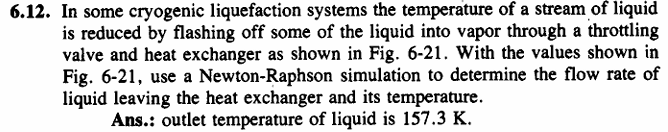
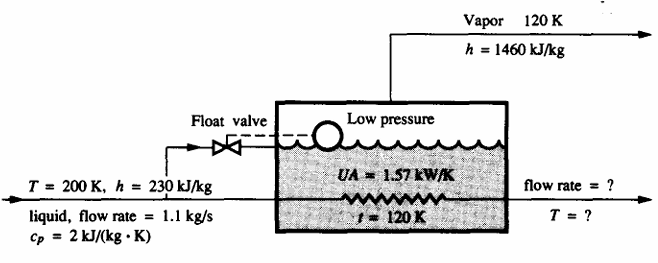

In [ ]:
# PROBLEMA STOECKER 6.12
# Paso 1: Definimos nuestras variables
T1 = 200      # K          Temperatura de entrada del líquido
H1 = 230      # kJ/kg      Entalpía del líquido de entrada
M1 = 1.1      # kg/s       Flujo másico de entrada
Cp = 2        # kJ/(kg·K)  Calor específico promedio del líquido
HVAP = 1460   # kJ/kg      Entalpía del vapor
UA = 1.57     # kW/K       Producto del coeficiente global de transferencia de calor por el área
Tfrio = 120   # K          Temperatura del lado frío

# Paso 2: Definimos el sistema de ecuaciones no lineales (SENL)
def sistema(vars):
    MVAP, T2, M2, LMTD, Q = vars
    H2 = H1   # La entalpía del líquido restante permanece igual por el estrangulamiento
    # Balance de energía por vaporización en el tanque/intercambiador
    eq1 = MVAP * (HVAP - H2) - Q
    # Balance de energía del líquido remanente
    eq2 = M2 * Cp * (T2 - T1) + Q
    # LMTD
    eq3 = LMTD - (((T1 - Tfrio) - (T2 - Tfrio)) / np.log((T1 - Tfrio) / (T2 - Tfrio)))
    # Transferencia de calor
    eq4 = Q - UA * LMTD
    # Balance de masa global
    eq5 = M2 + MVAP - M1

    return [eq1, eq2, eq3, eq4, eq5]

# Suposiciones iniciales
x0 = [0.07, 157, 1.03, 56, 88]

# Paso 3: Resolvemos el sistema
sol = fsolve(sistema, x0)

MVAP, T2, M2, LMTD, Q = sol
H2 = H1

# Paso 4: Tabla de resultados
tabla = pd.DataFrame({
    "Variable": ["MVAP", "T2", "M2", "LMTD", "Q"],
    "Valor": [MVAP, T2, M2, LMTD, Q],
    "Unidad": ["kg/s", "K", "kg/s", "K", "kW"]
})

tabla["Valor"] = tabla["Valor"].round(6)
display(tabla.style.hide(axis="index"))

Variable,Valor,Unidad
MVAP,0.071425,kg/s
T2,157.294095,K
M2,1.028575,kg/s
LMTD,55.956988,K
Q,87.852471,kW


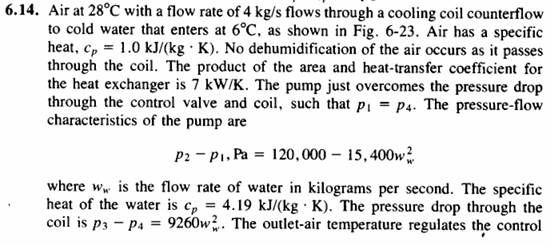

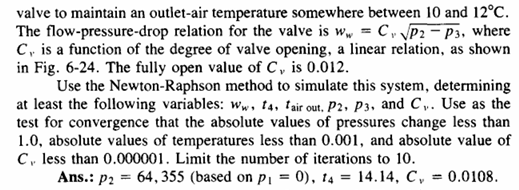

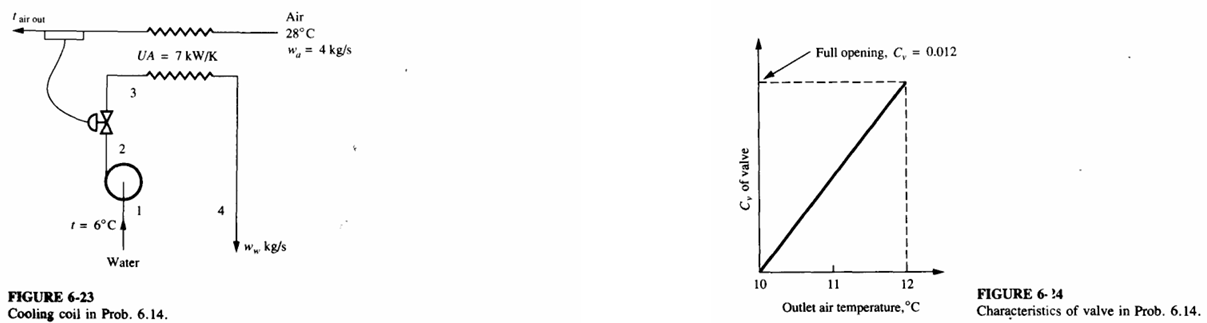

In [ ]:
# PROBLEMA 6.14 STOECKER
# Paso 1: Definimos nuestras variables
Wa = 4          # kg/s        Flujo másico de aire
Tairin = 28     # °C          Temperatura de entrada del aire
Tw1_in = 6      # °C          Temperatura de entrada del agua
cp_a = 1.0      # kJ/(kg·K)   Calor específico del aire
cp_w = 4.19     # kJ/(kg·K)   Calor específico del agua
UA = 7          # kW/K        Producto del coeficiente global de transferencia de calor por el área
P1 = 0          # Pa          Presión de referencia a la entrada de la bomba
P4 = 0          # Pa          Presión de referencia a la salida del serpentín

Cv_max = 0.012  # Valor máximo de Cv con válvula completamente abierta
K_pump = 15400  # Pa·s^2/kg^2 Constante de la bomba
K_coil = 9260   # Pa·s^2/kg^2 Constante del serpentín

# Paso 2: Obtenemos la ecuación lineal de Cv a partir de la figura
# Punto 1: (Tairout = 10 °C, Cv = 0)
# Punto 2: (Tairout = 12 °C, Cv = 0.012)

x1, y1 = 10, 0
x2, y2 = 12, 0.012

m = (y2 - y1) / (x2 - x1)     # pendiente
b = y1 - m*x1                 # ecuación de la linea recta

display(Markdown("### Ecuación de la válvula"))
display(Markdown(f"$C_v = {m:.6f}\\,T_{{airout}} {b:+.6f}$"))

# Paso 4: Definimos el sistema de ecuaciones no lineales (SENL)
def sistema(vars):
    Tairout, Tw4, DTm, Q, P2, P3, Ww, Cv = vars

    # INTERCAMBIADOR DE CALOR
    eq1 = Wa * cp_a * (Tairout - Tairin) + Q
    eq2 = Ww * cp_w * (Tw4 - Tw1_in) - Q
    eq3 = DTm - ((Tairin - Tw4) - (Tairout - Tw1_in)) / np.log((Tairin - Tw4) / (Tairout - Tw1_in))
    eq4 = UA * DTm - Q

    # ECUACIONES DE PRESIÓN
    eq5 = 120000 - K_pump * (Ww**2) - (P2 - P1)
    eq6 = K_coil * (Ww**2) - (P3 - P4)
    eq7 = Cv * np.sqrt(P2 - P3) - Ww

    # ECUACIÓN DE LA VÁLVULA
    eq8 = m * Tairout + b - Cv

    return [eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8]

# Suposiciones iniciales
x0 = [10.4, 12.4, 10, 241, 80000, 40000, 1, 0.0001]

# Paso 5: Resolvemos el SENL
sol = fsolve(sistema, x0)

Tairout, Tw4, DTm, Q, P2, P3, Ww, Cv = sol

# Paso 6: Tabla de resultados
tabla = pd.DataFrame({
    "Variable": ["Tairout", "Tw4", "DTm", "Q", "P2", "P3", "Ww", "Cv"],
    "Valor": [Tairout, Tw4, DTm, Q, P2, P3, Ww, Cv],
    "Unidad": ["°C", "°C", "K", "kW", "Pa", "Pa", "kg/s", "-"]
})

tabla["Valor"] = tabla["Valor"].round(6)
display(tabla.style.hide(axis="index"))

### Ecuación de la válvula

$C_v = 0.006000\,T_{airout} -0.060000$

Variable,Valor,Unidad
Tairout,11.802390,°C
Tw4,14.134767,°C
DTm,9.255777,K
Q,64.790442,kW
P2,64355.234559,Pa
P3,33459.125194,Pa
Ww,1.900867,kg/s
Cv,0.010814,-


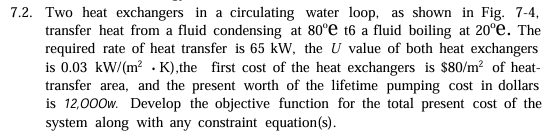


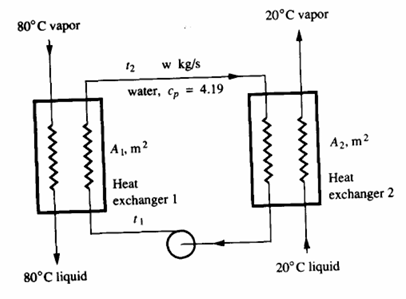

In [ ]:
# PROBLEMA STOECKER 7.2
# Paso 1: Definimos nuestras variables
Q1 = 65          # kW         Carga térmica en el intercambiador 1
Q2 = 65          # kW         Carga térmica en el intercambiador 2
U  = 0.03        # kW/(m^2·K) Coeficiente global de transferencia de calor
Cp = 4.19        # kJ/(kg·K)  Calor específico del agua

# Paso 2: Definimos una función auxiliar para la LMTD
def LMTD(dT1, dT2):
    if dT1 <= 0 or dT2 <= 0:
        return 1e20
    if abs(dT1 - dT2) < 1e-10:
        return dT1
    return (dT1 - dT2) / np.log(dT1 / dT2)

# Paso 3: Definimos la función objetivo
def objetivo(vars):
    T1, T2, M1, M2, W, A1, A2 = vars
    return 80 * (A1 + A2) + 12000 * W

# Paso 4: Definimos el sistema de restricciones
def sistema(vars):
    T1, T2, M1, M2, W, A1, A2 = vars

    lmtd1 = LMTD(80 - T2, 80 - T1)
    lmtd2 = LMTD(T2 - 20, T1 - 20)

    # Restricciones de igualdad
    eq1 = Q1 - U * A1 * lmtd1
    eq2 = Q1 - W * Cp * (T2 - T1)
    eq3 = Q1 - M1 * 2308.8
    eq4 = Q2 - U * A2 * lmtd2
    eq5 = Q2 + W * Cp * (T1 - T2)
    eq6 = Q2 - M2 * 2454.3

    return [eq1, eq2, eq3, eq4, eq5, eq6]

# Paso 5: Agrupamos las restricciones para minimize con SLSQP
restricciones = [
    {'type': 'eq', 'fun': lambda vars: sistema(vars)[0]},
    {'type': 'eq', 'fun': lambda vars: sistema(vars)[1]},
    {'type': 'eq', 'fun': lambda vars: sistema(vars)[2]},
    {'type': 'eq', 'fun': lambda vars: sistema(vars)[3]},
    {'type': 'eq', 'fun': lambda vars: sistema(vars)[4]},
    {'type': 'eq', 'fun': lambda vars: sistema(vars)[5]},
]

# Paso 6: Definimos los límites de las variables
limites = [
    (21.5, 75),     # T1
    (26, 75),       # T2
    (0.005, 0.081), # M1
    (0.004, 0.081), # M2
    (0.015, 1.55),  # W
    (10.5, 155),    # A1
    (10, 175)       # A2
]

# Paso 7: Definimos valores iniciales
x0 = [31.607, 68.393, 0.028, 0.026, 0.422, 84.093, 84.093]

# Paso 8: Resolvemos el problema de optimización
sol = minimize(
    objetivo,
    x0,
    method='SLSQP',
    bounds=limites,
    constraints=restricciones
)

# Paso 9: Extraemos resultados
T1, T2, M1, M2, W, A1, A2 = sol.x
PROFIT = sol.fun

# Paso 10: Tabla de resultados
tabla = pd.DataFrame({
    "Variable": ["T1", "T2", "M1", "M2", "W", "A1", "A2", "PROFIT"],
    "Valor": [T1, T2, M1, M2, W, A1, A2, PROFIT],
    "Unidad": ["°C", "°C", "kg/s", "kg/s", "kg/s", "m²", "m²", "$"]
})

tabla["Valor"] = tabla["Valor"].round(6)
display(tabla.style.hide(axis="index"))

# Paso 11: Mensaje de convergencia
print("¿Convergió el método?:", sol.success)
print("Mensaje del solver:", sol.message)

Variable,Valor,Unidad
T1,31.606975,°C
T2,68.393686,°C
M1,0.028153,kg/s
M2,0.026484,kg/s
W,0.421705,kg/s
A1,84.095057,m²
A2,84.092509,m²
PROFIT,18515.460920,$


¿Convergió el método?: True
Mensaje del solver: Optimization terminated successfully


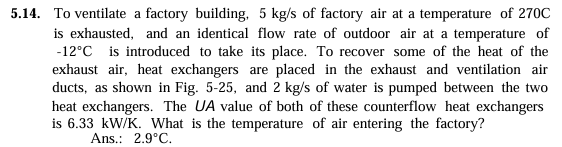


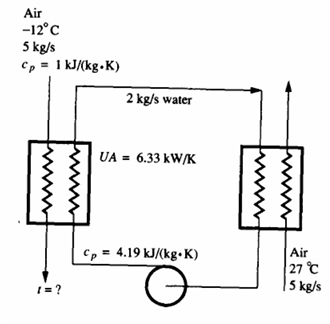

In [ ]:
# PROBLEMA 5.14 STOECKER
# Paso 1: Definimos nuestras variables conocidas
maire = 5        # kg/s         Flujo másico de aire
cp_aire = 1      # kJ/(kg·K)    Calor específico del aire
T0 = 27          # °C           Temperatura del aire caliente de entrada
T5 = -12         # °C           Temperatura del aire frío de entrada
magua = 2        # kg/s         Flujo másico de agua
cp_agua = 4.19   # kJ/(kg·K)    Calor específico del agua
UA = 6.33        # kW/K         Producto del coeficiente global de transferencia de calor por el área

# Paso 2: Definimos el sistema de ecuaciones no lineales (SENL)
def sistema(vars):
    Q1, Q2, T1, T2, T3, T4, DTm1, DTm2 = vars

    # Intercambiador 1
    eq1 = UA * DTm1 - Q1
    eq2 = -Q1 - maire * cp_aire * (T1 - T0)
    eq3 = Q1 - magua * cp_agua * (T3 - T2)

    # Intercambiador 2
    eq4 = UA * DTm2 - Q2
    eq5 = -Q2 - magua * cp_agua * (T2 - T3)
    eq6 = Q2 - maire * cp_aire * (T4 - T5)

    # LMTD intercambiador 1
    eq7 = DTm1 - ((T0 - T3) - (T1 - T2)) / np.log((T0 - T3) / (T1 - T2))

    # LMTD intercambiador 2
    eq8 = DTm2 - ((T2 - T5) - (T3 - T4)) / np.log((T2 - T5) / (T3 - T4))

    return [eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8]

# Suposiciones iniciales
x0 = [100, 78, 14, 10, 7, 6, 15, 10]

# Paso 3: Resolvemos el SENL
sol = fsolve(sistema, x0)

Q1, Q2, T1, T2, T3, T4, DTm1, DTm2 = sol

# Paso 4: Tabla de resultados
tabla = pd.DataFrame({
    "Variable": ["Q1", "Q2", "T1", "T2", "T3", "T4"],
    "Valor": [Q1, Q2, T1, T2, T3, T4],
    "Unidad": ["kW", "kW", "°C", "°C", "°C", "°C"]
})

tabla["Valor"] = tabla["Valor"].round(6)
display(tabla.style.hide(axis="index"))

Variable,Valor,Unidad
Q1,74.599546,kW
Q2,74.599546,kW
T1,12.080091,°C
T2,3.048953,°C
T3,11.951047,°C
T4,2.919909,°C


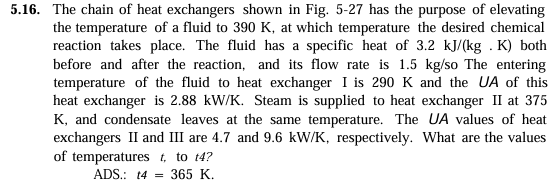

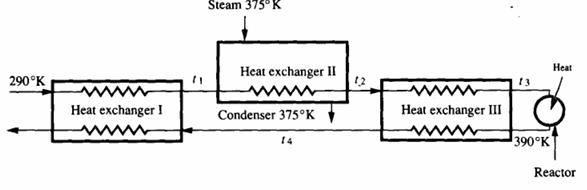

In [ ]:
# PROBLEMA 5.16 STOECKER
# Paso 1: Definimos nuestras variables conocidas
mfluido = 1.5     # kg/s         Flujo másico del fluido de proceso
cp_fluido = 3.2   # kJ/(kg·K)    Calor específico del fluido
T0 = 290          # K            Temperatura de entrada al intercambiador I
Tsr = 390         # K            Temperatura de salida del reactor
Tsteam = 375      # K            Temperatura del vapor en el intercambiador II

UA1 = 2.88        # kW/K         Producto U*A del intercambiador I
UA2 = 4.7         # kW/K         Producto U*A del intercambiador II
UA3 = 9.6         # kW/K         Producto U*A del intercambiador III

# Paso 2: Definimos una función auxiliar para la LMTD
def LMTD(dT1, dT2):
    if dT1 <= 0 or dT2 <= 0:
        return 1e20
    if abs(dT1 - dT2) < 1e-10:
        return dT1
    return (dT1 - dT2) / np.log(dT1 / dT2)

# Paso 3: Definimos el sistema de ecuaciones no lineales (SENL)
def sistema(vars):
    Q1, Q2, Q3, DTm1, DTm2, DTm3, T1, T5, T2, T4, T3 = vars

    # Intercambiador I
    eq1 = UA1 * DTm1 - Q1
    eq2 = DTm1 - LMTD(T4 - T1, T5 - T0)
    eq3 = Q1 - mfluido * cp_fluido * (T1 - T0)
    eq4 = Q1 - mfluido * cp_fluido * (T4 - T5)

    # Intercambiador II
    eq5 = UA2 * DTm2 - Q2
    eq6 = DTm2 - LMTD(Tsteam - T1, Tsteam - T2)
    eq7 = Q2 - mfluido * cp_fluido * (T2 - T1)

    # Intercambiador III
    eq8  = UA3 * DTm3 - Q3
    eq9  = DTm3 - LMTD(Tsr - T3, T4 - T2)
    eq10 = Q3 - mfluido * cp_fluido * (T3 - T2)
    eq11 = Q3 - mfluido * cp_fluido * (Tsr - T4)

    return [eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8, eq9, eq10, eq11]

# Suposiciones iniciales
x0 = [
    135,   # Q1
    170,   # Q2
    115,   # Q3
    47,    # DTm1
    36,    # DTm2
    12,    # DTm3
    318,   # T1
    337,   # T5
    353,   # T2
    365,   # T4
    377    # T3
]

# Paso 4: Resolvemos el SENL
sol = fsolve(sistema, x0)

# Extraemos resultados
Q1, Q2, Q3, DTm1, DTm2, DTm3, T1, T5, T2, T4, T3 = sol

# Calculamos Q4 como resultado posterior
Q4 = mfluido * cp_fluido * (Tsr - T3)

# Paso 5: Tabla de resultados
tabla = pd.DataFrame({
    "Variable": ["Q1", "Q2", "Q3",  "T1", "T5", "T2", "T4", "T3", "Q4"],
    "Valor": [Q1, Q2, Q3, T1, T5, T2, T4, T3, Q4],
    "Unidad": ["kW", "kW", "kW"
    , "K", "K", "K", "K", "K", "kW"]
})

tabla["Valor"] = tabla["Valor"].round(6)
display(tabla.style.hide(axis="index"))

Variable,Valor,Unidad
Q1,136.504990,kW
Q2,169.514971,kW
Q3,115.986692,kW
T1,318.438540,K
T5,337.397566,K
T2,353.754159,K
T4,365.836106,K
T3,377.918053,K
Q4,57.993346,kW


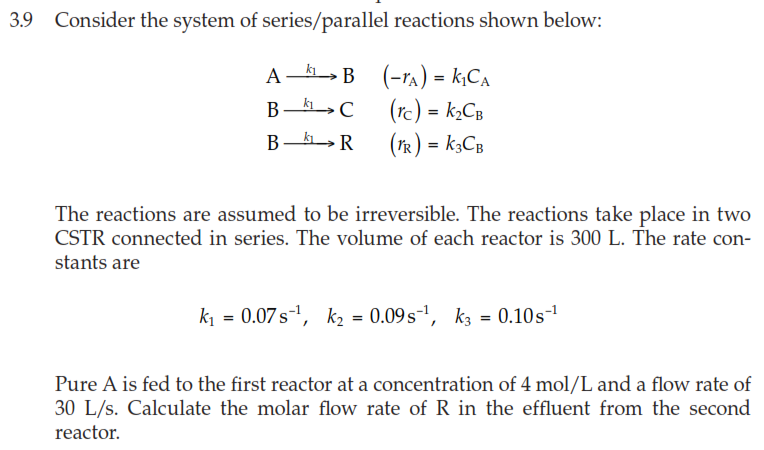

In [ ]:
# PROBLEMA 3.9 INTRODUCTION TO CHEMICAL REACTOR ANALYSIS
# Paso 1: Definimos nuestras variables
Cao = 4.0      # mol/L
Cbo = 0.0      # mol/L
Cco = 0.0      # mol/L
Cro = 0.0      # mol/L

k1 = 0.07      # s^-1
k2 = 0.09      # s^-1
k3 = 0.10      # s^-1

V = 300.0      # L
Vo = 30.0      # L/s
tau = V / Vo   # s

# Paso 2: Definimos el sistema de ecuaciones no lineales
def sistema(vars):
    Ca1, Cb1, Cc1, Cr1, Ca2, Cb2, Cc2, Cr2, Ra1, Rb1, Rc1, Rr1, Ra2, Rb2, Rc2, Rr2 = vars

    # Restricción para evitar concentraciones negativas
    if Ca1 < 0 or Cb1 < 0 or Cc1 < 0 or Cr1 < 0 or Ca2 < 0 or Cb2 < 0 or Cc2 < 0 or Cr2 < 0:
        return [1e6] * 16

    # BALANCES MOLARES DEL CSTR 1
    eq1 = -Ca1 + Cao + Ra1 * tau
    eq2 = -Cb1 + Cbo + Rb1 * tau
    eq3 = -Cc1 + Cco + Rc1 * tau
    eq4 = -Cr1 + Cro + Rr1 * tau

    # BALANCES MOLARES DEL CSTR 2
    eq5 = -Ca2 + Ca1 + Ra2 * tau
    eq6 = -Cb2 + Cb1 + Rb2 * tau
    eq7 = -Cc2 + Cc1 + Rc2 * tau
    eq8 = -Cr2 + Cr1 + Rr2 * tau

    # VELOCIDADES NETAS CSTR 1
    eq9  = -k1 * Ca1 - Ra1
    eq10 = k1 * Ca1 - k2 * Cb1 - k3 * Cb1 - Rb1
    eq11 = k2 * Cb1 - Rc1
    eq12 = k3 * Cb1 - Rr1

    # VELOCIDADES NETAS CSTR 2
    eq13 = -k1 * Ca2 - Ra2
    eq14 = k1 * Ca2 - k2 * Cb2 - k3 * Cb2 - Rb2
    eq15 = k2 * Cb2 - Rc2
    eq16 = k3 * Cb2 - Rr2

    return [eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8,
            eq9, eq10, eq11, eq12, eq13, eq14, eq15, eq16]

# Suposición inicial
guess = [10, 10, 10, 10,
         10, 10, 10, 10,
         10, 10, 10, 10,
         10, 10, 10, 10]

# Paso 3: Resolver el sistema
sol = fsolve(sistema, guess)

Ca1, Cb1, Cc1, Cr1, Ca2, Cb2, Cc2, Cr2, Ra1, Rb1, Rc1, Rr1, Ra2, Rb2, Rc2, Rr2 = sol

# Paso 4: Cálculo del flujo molar de R a la salida del reactor 2
FR2 = Cr2 * Vo   # mol/s

# Paso 5: Tabla de resultados
tabla_resumen = pd.DataFrame({
    "Variable": ["Ca1", "Cb1", "Cc1", "Cr1",
                 "Ca2", "Cb2", "Cc2", "Cr2",
                 "Ra1", "Rb1", "Rc1", "Rr1",
                 "Ra2", "Rb2", "Rc2", "Rr2",
                 "FR2"],
    "Valor": [Ca1, Cb1, Cc1, Cr1,
              Ca2, Cb2, Cc2, Cr2,
              Ra1, Rb1, Rc1, Rr1,
              Ra2, Rb2, Rc2, Rr2,
              FR2],
    "Unidad": ["mol/L", "mol/L", "mol/L", "mol/L",
               "mol/L", "mol/L", "mol/L", "mol/L",
               "mol/(L·s)", "mol/(L·s)", "mol/(L·s)", "mol/(L·s)",
               "mol/(L·s)", "mol/(L·s)", "mol/(L·s)", "mol/(L·s)",
               "mol/s"]
})

tabla_resumen["Valor"] = tabla_resumen["Valor"].round(6)
display(tabla_resumen.style.hide(axis="index"))

# Paso 6: Imprimir el resultado principal
print(f"El flujo molar de R en el efluente del segundo reactor es {FR2:.6f} mol/s")

Variable,Valor,Unidad
Ca1,2.352941,mol/L
Cb1,0.567951,mol/L
Cc1,0.511156,mol/L
Cr1,0.567951,mol/L
Ca2,1.384083,mol/L
Cb2,0.529934,mol/L
Cc2,0.988097,mol/L
Cr2,1.097886,mol/L
Ra1,-0.164706,mol/(L·s)
Rb1,0.056795,mol/(L·s)


El flujo molar de R en el efluente del segundo reactor es 32.936568 mol/s


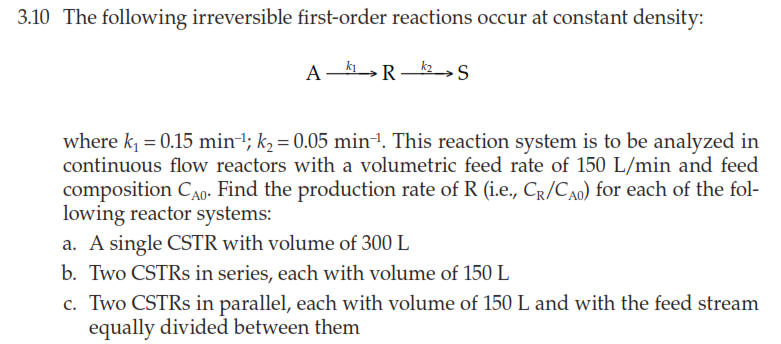

In [ ]:
# PROBLEMA 3.10 INTRODUCTION TO CHEMICAL REACTOR ANALYSIS
# Paso 1: Definimos nuestras variables
Cao = 1.0         # mol/L
Cro = 0.0         # mol/L
Cso = 0.0         # mol/L

k1 = 0.15         # min^-1
k2 = 0.05         # min^-1

Vo_total = 150.0  # L/min

# Paso 2: Definimos la función para un solo CSTR
def sistema_cstr(vars, Cao, Cro, Cso, k1, k2, tau):
    Ca, Cr, Cs, Ra, Rr, Rs = vars

    if Ca < 0 or Cr < 0 or Cs < 0:
        return [1e6] * 6

    # BALANCES MOLARES DEL CSTR
    eq1 = -Ca + Cao + Ra * tau
    eq2 = -Cr + Cro + Rr * tau
    eq3 = -Cs + Cso + Rs * tau

    # VELOCIDADES NETAS
    eq4 = -k1 * Ca - Ra
    eq5 = k1 * Ca - k2 * Cr - Rr
    eq6 = k2 * Cr - Rs

    return [eq1, eq2, eq3, eq4, eq5, eq6]

# Paso 3: Definimos la función para dos CSTR en serie
def sistema_serie(vars, Cao, Cro, Cso, k1, k2, tau):
    Ca1, Cr1, Cs1, Ca2, Cr2, Cs2, Ra1, Rr1, Rs1, Ra2, Rr2, Rs2 = vars

    if Ca1 < 0 or Cr1 < 0 or Cs1 < 0 or Ca2 < 0 or Cr2 < 0 or Cs2 < 0:
        return [1e6] * 12

    # BALANCES MOLARES DEL CSTR 1
    eq1 = -Ca1 + Cao + Ra1 * tau
    eq2 = -Cr1 + Cro + Rr1 * tau
    eq3 = -Cs1 + Cso + Rs1 * tau

    # BALANCES MOLARES DEL CSTR 2
    eq4 = -Ca2 + Ca1 + Ra2 * tau
    eq5 = -Cr2 + Cr1 + Rr2 * tau
    eq6 = -Cs2 + Cs1 + Rs2 * tau

    # VELOCIDADES NETAS CSTR 1
    eq7 = -k1 * Ca1 - Ra1
    eq8 = k1 * Ca1 - k2 * Cr1 - Rr1
    eq9 = k2 * Cr1 - Rs1

    # VELOCIDADES NETAS CSTR 2
    eq10 = -k1 * Ca2 - Ra2
    eq11 = k1 * Ca2 - k2 * Cr2 - Rr2
    eq12 = k2 * Cr2 - Rs2

    return [eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8, eq9, eq10, eq11, eq12]

# Paso 4: Resolvemos el inciso a) Un solo CSTR de 300 L
V_a = 300.0       # L
Vo_a = Vo_total   # L/min
tau_a = V_a / Vo_a

guess_a = [10, 10, 10, 10, 10, 10]

sol_a = fsolve(sistema_cstr, guess_a, args=(Cao, Cro, Cso, k1, k2, tau_a))
Ca_a, Cr_a, Cs_a, Ra_a, Rr_a, Rs_a = sol_a

razon_a = Cr_a / Cao

tabla_a = pd.DataFrame({
    "Variable": ["Ca", "Cr", "Cs", "Ra", "Rr", "Rs", "Cr/Cao"],
    "Valor": [Ca_a, Cr_a, Cs_a, Ra_a, Rr_a, Rs_a, razon_a],
    "Unidad": ["mol/L", "mol/L", "mol/L", "mol/(L·min)", "mol/(L·min)", "mol/(L·min)", "adimensional"]
})
tabla_a["Valor"] = tabla_a["Valor"].round(6)

# Paso 5: Resolvemos el inciso b) Dos CSTR en serie, cada uno de 150 L
V_b = 150.0       # L
Vo_b = Vo_total   # L/min
tau_b = V_b / Vo_b

guess_b = [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]

sol_b = fsolve(sistema_serie, guess_b, args=(Cao, Cro, Cso, k1, k2, tau_b))
Ca1_b, Cr1_b, Cs1_b, Ca2_b, Cr2_b, Cs2_b, Ra1_b, Rr1_b, Rs1_b, Ra2_b, Rr2_b, Rs2_b = sol_b

razon_b = Cr2_b / Cao

tabla_b = pd.DataFrame({
    "Variable": ["Ca1", "Cr1", "Cs1", "Ca2", "Cr2", "Cs2",
                 "Ra1", "Rr1", "Rs1", "Ra2", "Rr2", "Rs2", "Cr2/Cao"],
    "Valor": [Ca1_b, Cr1_b, Cs1_b, Ca2_b, Cr2_b, Cs2_b,
              Ra1_b, Rr1_b, Rs1_b, Ra2_b, Rr2_b, Rs2_b, razon_b],
    "Unidad": ["mol/L", "mol/L", "mol/L", "mol/L", "mol/L", "mol/L",
               "mol/(L·min)", "mol/(L·min)", "mol/(L·min)",
               "mol/(L·min)", "mol/(L·min)", "mol/(L·min)",
               "adimensional"]
})
tabla_b["Valor"] = tabla_b["Valor"].round(6)

# Paso 6: Resolvemos el inciso c) Dos CSTR en paralelo, cada uno de 150 L
V_c = 150.0            # L
Vo_c = Vo_total / 2    # L/min
tau_c = V_c / Vo_c

guess_c = [10, 10, 10, 10, 10, 10]

sol_c = fsolve(sistema_cstr, guess_c, args=(Cao, Cro, Cso, k1, k2, tau_c))
Ca_c, Cr_c, Cs_c, Ra_c, Rr_c, Rs_c = sol_c

razon_c = Cr_c / Cao

tabla_c = pd.DataFrame({
    "Variable": ["Ca", "Cr", "Cs", "Ra", "Rr", "Rs", "Cr/Cao"],
    "Valor": [Ca_c, Cr_c, Cs_c, Ra_c, Rr_c, Rs_c, razon_c],
    "Unidad": ["mol/L", "mol/L", "mol/L", "mol/(L·min)", "mol/(L·min)", "mol/(L·min)", "adimensional"]
})
tabla_c["Valor"] = tabla_c["Valor"].round(6)

# Paso 7: Mostramos los resultados de cada sistema
display(Markdown("### Resultados para un solo CSTR"))
display(tabla_a.style.hide(axis="index"))

display(Markdown("### Resultados para dos CSTR en serie"))
display(tabla_b.style.hide(axis="index"))

display(Markdown("### Resultados para dos CSTR en paralelo"))
display(tabla_c.style.hide(axis="index"))

# Paso 8: Generamos la tabla resumen final
tabla_final = pd.DataFrame({
    "Sistema": ["Un solo CSTR", "Dos CSTR en serie", "Dos CSTR en paralelo"],
    "Cr/Cao": [razon_a, razon_b, razon_c]
})
tabla_final["Cr/Cao"] = tabla_final["Cr/Cao"].round(6)

display(Markdown("### Resumen final de Cr/Cao"))
display(tabla_final.style.hide(axis="index"))

### Resultados para un solo CSTR

Variable,Valor,Unidad
Ca,0.769231,mol/L
Cr,0.209790,mol/L
Cs,0.020979,mol/L
Ra,-0.115385,mol/(L·min)
Rr,0.104895,mol/(L·min)
Rs,0.010490,mol/(L·min)
Cr/Cao,0.209790,adimensional


### Resultados para dos CSTR en serie

Variable,Valor,Unidad
Ca1,0.869565,mol/L
Cr1,0.124224,mol/L
Cs1,0.006211,mol/L
Ca2,0.756144,mol/L
Cr2,0.226329,mol/L
Cs2,0.017528,mol/L
Ra1,-0.130435,mol/(L·min)
Rr1,0.124224,mol/(L·min)
Rs1,0.006211,mol/(L·min)
Ra2,-0.113422,mol/(L·min)


### Resultados para dos CSTR en paralelo

Variable,Valor,Unidad
Ca,0.769231,mol/L
Cr,0.209790,mol/L
Cs,0.020979,mol/L
Ra,-0.115385,mol/(L·min)
Rr,0.104895,mol/(L·min)
Rs,0.010490,mol/(L·min)
Cr/Cao,0.209790,adimensional


### Resumen final de Cr/Cao

Sistema,Cr/Cao
Un solo CSTR,0.209790
Dos CSTR en serie,0.226329
Dos CSTR en paralelo,0.209790


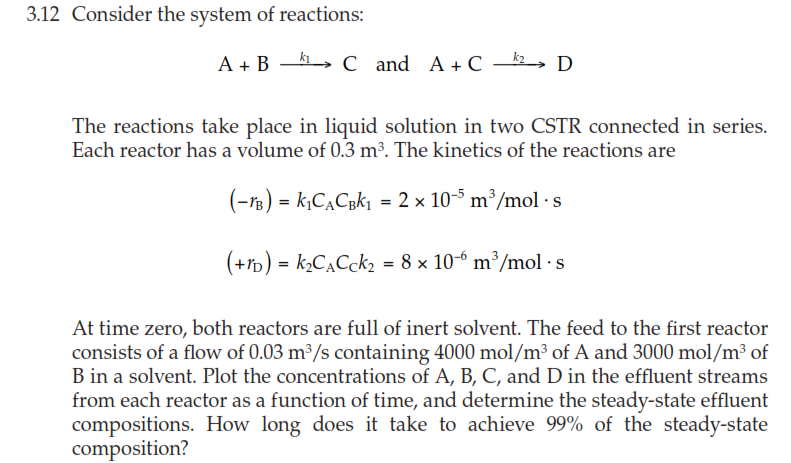

### Gráfica de concentraciones en el efluente del reactor 1

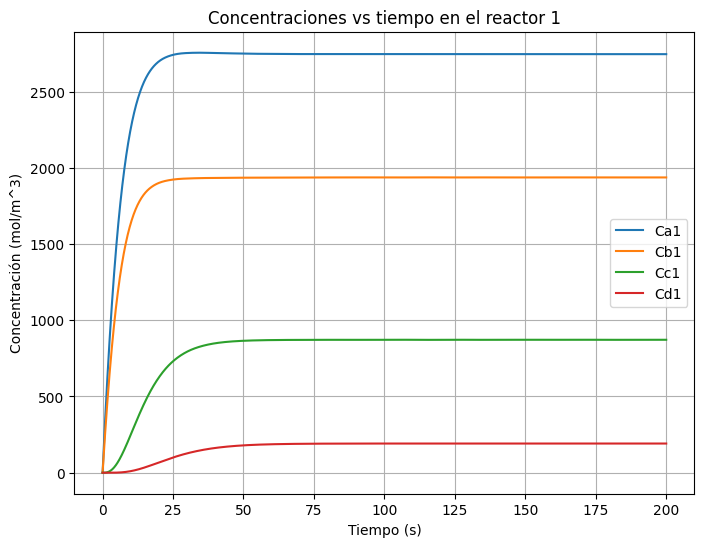

### Gráfica de concentraciones en el efluente del reactor 2

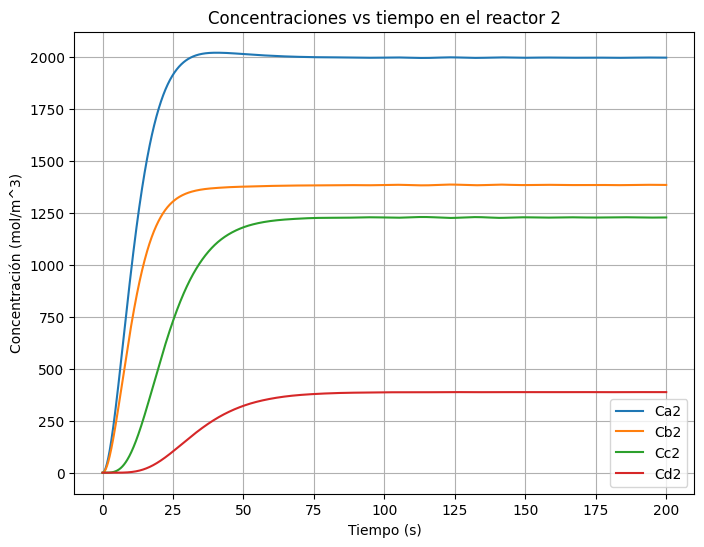

### Composiciones de estado estacionario

Variable,Valor de estado estacionario,Unidad
Ca1,2745.208992,mol/m^3
Cb1,1936.681117,mol/m^3
Cc1,871.846758,mol/m^3
Cd1,191.472125,mol/m^3
Ca2,1996.407125,mol/m^3
Cb2,1384.054045,mol/m^3
Cc2,1228.299034,mol/m^3
Cd2,387.646920,mol/m^3


### Tiempo para alcanzar 99% del estado estacionario

Sistema,Tiempo al 99% (s)
Reactor 1,69.634817
Reactor 2,84.542271
Sistema completo,84.542271


In [ ]:
# PROBLEMA 3.12 INTRODUCTION TO CHEMICAL REACTOR ANALYSIS
# Paso 1: Definimos nuestras variables
Cao = 4000.0    # mol/m^3
Cbo = 3000.0    # mol/m^3
Cco = 0.0       # mol/m^3
Cdo = 0.0       # mol/m^3

k1 = 2e-5       # m^3/(mol·s)
k2 = 8e-6       # m^3/(mol·s)

V = 0.3         # m^3
Vo = 0.03       # m^3/s
tau = V / Vo    # s

# Paso 2: Calculamos primero el estado estacionario con ecuaciones no lineales
def sistema_estacionario(vars):
    Ca1, Cb1, Cc1, Cd1, Ca2, Cb2, Cc2, Cd2, Ra1, Rb1, Rc1, Rd1, Ra2, Rb2, Rc2, Rd2 = vars

    if min(Ca1, Cb1, Cc1, Cd1, Ca2, Cb2, Cc2, Cd2) < 0:
        return [1e6] * 16

    # BALANCES MOLARES DEL CSTR 1
    eq1 = -Ca1 + Cao + Ra1 * tau
    eq2 = -Cb1 + Cbo + Rb1 * tau
    eq3 = -Cc1 + Cco + Rc1 * tau
    eq4 = -Cd1 + Cdo + Rd1 * tau

    # BALANCES MOLARES DEL CSTR 2
    eq5 = -Ca2 + Ca1 + Ra2 * tau
    eq6 = -Cb2 + Cb1 + Rb2 * tau
    eq7 = -Cc2 + Cc1 + Rc2 * tau
    eq8 = -Cd2 + Cd1 + Rd2 * tau

    # VELOCIDADES NETAS CSTR 1
    eq9  = -k1 * Ca1 * Cb1 - k2 * Ca1 * Cc1 - Ra1
    eq10 = -k1 * Ca1 * Cb1 - Rb1
    eq11 =  k1 * Ca1 * Cb1 - k2 * Ca1 * Cc1 - Rc1
    eq12 =  k2 * Ca1 * Cc1 - Rd1

    # VELOCIDADES NETAS CSTR 2
    eq13 = -k1 * Ca2 * Cb2 - k2 * Ca2 * Cc2 - Ra2
    eq14 = -k1 * Ca2 * Cb2 - Rb2
    eq15 =  k1 * Ca2 * Cb2 - k2 * Ca2 * Cc2 - Rc2
    eq16 =  k2 * Ca2 * Cc2 - Rd2

    return [eq1, eq2, eq3, eq4,
            eq5, eq6, eq7, eq8,
            eq9, eq10, eq11, eq12,
            eq13, eq14, eq15, eq16]

guess = [10, 10, 10, 10,
         10, 10, 10, 10,
         10, 10, 10, 10,
         10, 10, 10, 10]

sol_ss = fsolve(sistema_estacionario, guess)

Ca1_ss, Cb1_ss, Cc1_ss, Cd1_ss, Ca2_ss, Cb2_ss, Cc2_ss, Cd2_ss, \
Ra1_ss, Rb1_ss, Rc1_ss, Rd1_ss, Ra2_ss, Rb2_ss, Rc2_ss, Rd2_ss = sol_ss

# Paso 3: Definimos el modelo dinámico
# y = [Ca1, Cb1, Cc1, Cd1, Ca2, Cb2, Cc2, Cd2]
def modelo_dinamico(t, y):
    Ca1, Cb1, Cc1, Cd1, Ca2, Cb2, Cc2, Cd2 = y

    # Velocidades de reacción en el reactor 1
    r1_1 = k1 * Ca1 * Cb1
    r2_1 = k2 * Ca1 * Cc1

    # Velocidades de reacción en el reactor 2
    r1_2 = k1 * Ca2 * Cb2
    r2_2 = k2 * Ca2 * Cc2

    # Reactor 1
    dCa1dt = (Vo/V) * (Cao - Ca1) - r1_1 - r2_1
    dCb1dt = (Vo/V) * (Cbo - Cb1) - r1_1
    dCc1dt = (Vo/V) * (Cco - Cc1) + r1_1 - r2_1
    dCd1dt = (Vo/V) * (Cdo - Cd1) + r2_1

    # Reactor 2
    dCa2dt = (Vo/V) * (Ca1 - Ca2) - r1_2 - r2_2
    dCb2dt = (Vo/V) * (Cb1 - Cb2) - r1_2
    dCc2dt = (Vo/V) * (Cc1 - Cc2) + r1_2 - r2_2
    dCd2dt = (Vo/V) * (Cd1 - Cd2) + r2_2

    return [dCa1dt, dCb1dt, dCc1dt, dCd1dt, dCa2dt, dCb2dt, dCc2dt, dCd2dt]

# Paso 4: Condiciones iniciales
# Ambos reactores llenos de solvente inerte al tiempo cero
y0 = [0, 0, 0, 0, 0, 0, 0, 0]

# Paso 5: Resolvemos el sistema dinámico
t_inicial = 0
t_final = 200      # s, suficiente para observar el acercamiento al estado estacionario
n_puntos = 2000
t_eval = np.linspace(t_inicial, t_final, n_puntos)

sol_din = solve_ivp(modelo_dinamico, [t_inicial, t_final], y0, t_eval=t_eval, method='RK45')

t = sol_din.t
Ca1 = sol_din.y[0]
Cb1 = sol_din.y[1]
Cc1 = sol_din.y[2]
Cd1 = sol_din.y[3]
Ca2 = sol_din.y[4]
Cb2 = sol_din.y[5]
Cc2 = sol_din.y[6]
Cd2 = sol_din.y[7]

# Paso 6: Graficamos concentraciones del reactor 1
display(Markdown("### Gráfica de concentraciones en el efluente del reactor 1"))

plt.figure(figsize=(8, 6))
plt.plot(t, Ca1, label='Ca1')
plt.plot(t, Cb1, label='Cb1')
plt.plot(t, Cc1, label='Cc1')
plt.plot(t, Cd1, label='Cd1')
plt.xlabel('Tiempo (s)')
plt.ylabel('Concentración (mol/m^3)')
plt.title('Concentraciones vs tiempo en el reactor 1')
plt.legend()
plt.grid(True)
plt.show()

# Paso 7: Graficamos concentraciones del reactor 2
display(Markdown("### Gráfica de concentraciones en el efluente del reactor 2"))

plt.figure(figsize=(8, 6))
plt.plot(t, Ca2, label='Ca2')
plt.plot(t, Cb2, label='Cb2')
plt.plot(t, Cc2, label='Cc2')
plt.plot(t, Cd2, label='Cd2')
plt.xlabel('Tiempo (s)')
plt.ylabel('Concentración (mol/m^3)')
plt.title('Concentraciones vs tiempo en el reactor 2')
plt.legend()
plt.grid(True)
plt.show()

# Paso 8: Definimos una función para encontrar el tiempo al 99% del estado estacionario
def tiempo_99(t, perfiles, estado_estacionario):
    perfiles = np.array(perfiles)
    estado_estacionario = np.array(estado_estacionario)

    tolerancia = 0.01 * np.abs(estado_estacionario)

    for i in range(len(t)):
        error = np.abs(perfiles[:, i] - estado_estacionario)
        if np.all(error <= tolerancia):
            return t[i]
    return None

# Tiempo al 99% para reactor 1
perfiles_r1 = [Ca1, Cb1, Cc1, Cd1]
estado_r1 = [Ca1_ss, Cb1_ss, Cc1_ss, Cd1_ss]
t99_r1 = tiempo_99(t, perfiles_r1, estado_r1)

# Tiempo al 99% para reactor 2
perfiles_r2 = [Ca2, Cb2, Cc2, Cd2]
estado_r2 = [Ca2_ss, Cb2_ss, Cc2_ss, Cd2_ss]
t99_r2 = tiempo_99(t, perfiles_r2, estado_r2)

# Tiempo al 99% del sistema completo
perfiles_total = [Ca1, Cb1, Cc1, Cd1, Ca2, Cb2, Cc2, Cd2]
estado_total = [Ca1_ss, Cb1_ss, Cc1_ss, Cd1_ss, Ca2_ss, Cb2_ss, Cc2_ss, Cd2_ss]
t99_total = tiempo_99(t, perfiles_total, estado_total)

# Paso 9: Tabla de resultados del estado estacionario
tabla_ss = pd.DataFrame({
    "Variable": ["Ca1", "Cb1", "Cc1", "Cd1", "Ca2", "Cb2", "Cc2", "Cd2"],
    "Valor de estado estacionario": [Ca1_ss, Cb1_ss, Cc1_ss, Cd1_ss, Ca2_ss, Cb2_ss, Cc2_ss, Cd2_ss],
    "Unidad": ["mol/m^3"] * 8
})

tabla_ss["Valor de estado estacionario"] = tabla_ss["Valor de estado estacionario"].round(6)

display(Markdown("### Composiciones de estado estacionario"))
display(tabla_ss.style.hide(axis="index"))

# Paso 10: Tabla con tiempos al 99%
tabla_99 = pd.DataFrame({
    "Sistema": ["Reactor 1", "Reactor 2", "Sistema completo"],
    "Tiempo al 99% (s)": [t99_r1, t99_r2, t99_total]
})

tabla_99["Tiempo al 99% (s)"] = tabla_99["Tiempo al 99% (s)"].round(6)

display(Markdown("### Tiempo para alcanzar 99% del estado estacionario"))
display(tabla_99.style.hide(axis="index"))


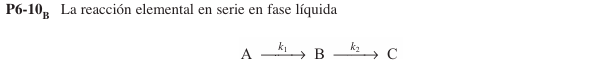

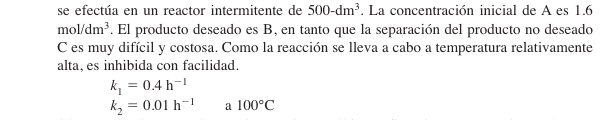


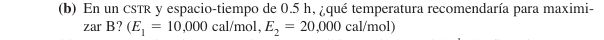

Variable,Valor,Unidad
T óptima,437.064003,K
Cb máximo,0.749892,mol/dm^3
Ca,0.656433,mol/dm^3
Cc,0.193675,mol/dm^3
k1,2.874832,h^-1
k2,0.516541,h^-1
ra,-1.887134,mol/dm^3·h
rb,1.499784,mol/dm^3·h
rc,0.387350,mol/dm^3·h


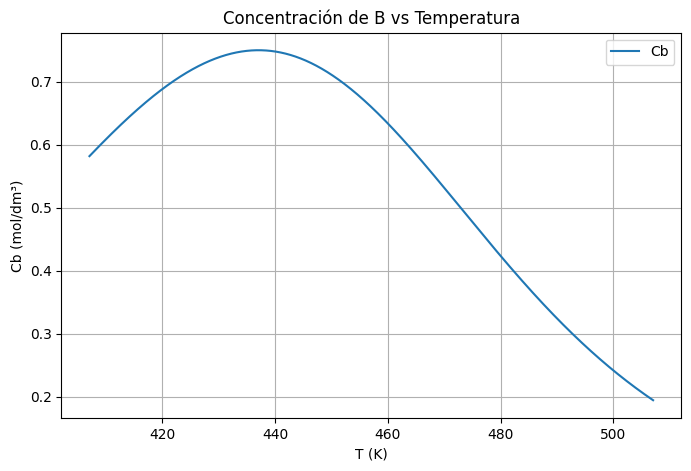

In [ ]:
# PROBLEMA P6-10 FOGLER
# Paso 1: Definimos nuestras variables
R = 1.987           # cal/mol*K
tau = 0.5           # h
Cao = 1.6           # mol/dm^3
k10 = 0.4           # h^-1 a 373.15 K
k20 = 0.01          # h^-1 a 373.15 K
E1 = 10000          # cal/mol
E2 = 20000          # cal/mol
T0 = 373.15         # K

# Paso 2: Definimos el barrido de temperatura
T = np.linspace(407.054, 507.054, 3000)

# Paso 3: Definimos las ecuaciones del problema

# Ecuaciones de Arrhenius
k1 = k10 * np.exp((E1 / R) * (1 / T0 - 1 / T))
k2 = k20 * np.exp((E2 / R) * (1 / T0 - 1 / T))

# Concentraciones en el CSTR
Ca = Cao / (1 + k1 * tau)                                 # A
Cb = (k1 * Cao * tau) / ((1 + k1 * tau) * (1 + k2 * tau)) # B
Cc = (k2 * Cb) * tau                                     # C

# Velocidades individuales
r1a = -k1 * Ca
r1b =  k1 * Ca
r2b = -k2 * Cb
r2c =  k2 * Cb

# Velocidades netas
ra = r1a
rb = r1b + r2b
rc = r2c

# Paso 4: Encontramos el valor máximo de Cb
indice_max = np.argmax(Cb)
T_opt = T[indice_max]
Cb_max = Cb[indice_max]

# Paso 5: Construimos la tabla de resultados
tabla_resumen = pd.DataFrame({
    "Variable": ["T óptima", "Cb máximo", "Ca", "Cc", "k1", "k2", "ra", "rb", "rc"],
    "Valor": [
        T_opt,
        Cb_max,
        Ca[indice_max],
        Cc[indice_max],
        k1[indice_max],
        k2[indice_max],
        ra[indice_max],
        rb[indice_max],
        rc[indice_max]
    ],
    "Unidad": [
        "K",
        "mol/dm^3",
        "mol/dm^3",
        "mol/dm^3",
        "h^-1",
        "h^-1",
        "mol/dm^3·h",
        "mol/dm^3·h",
        "mol/dm^3·h"
    ]
})

tabla_resumen["Valor"] = tabla_resumen["Valor"].round(6)
display(tabla_resumen.style.hide(axis="index"))

# Paso 6: Graficamos Cb vs T
plt.figure(figsize=(8,5))
plt.plot(T, Cb, label="Cb")
plt.xlabel("T (K)")
plt.ylabel("Cb (mol/dm³)")
plt.title("Concentración de B vs Temperatura")
plt.grid(True)
plt.legend()
plt.show()

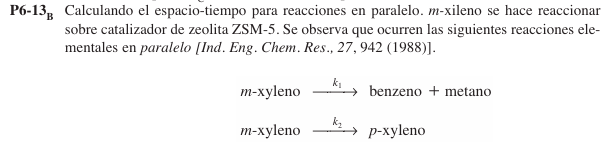

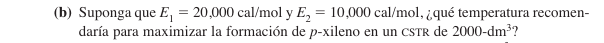

Variable,Valor,Unidad
T óptima,1193.731244,K
Cd máximo,0.013073,mol/dm^3
Ca,0.012219,mol/dm^3
Cb,0.012208,mol/dm^3
Cc,0.012208,mol/dm^3
k1,1.998241,min^-1
k2,2.139789,min^-1
ra,-0.050562,mol/dm^3·min
rb,0.024416,mol/dm^3·min
rc,0.024416,mol/dm^3·min


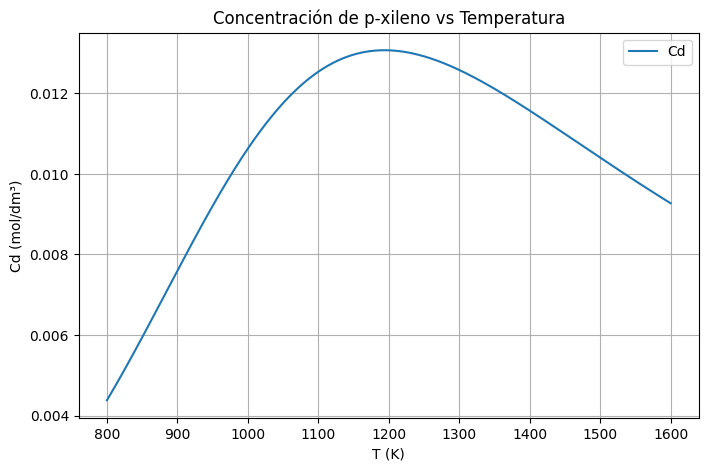

In [ ]:
# PROBLEMA P6-13 FOGLER
# Paso 1: Definimos nuestras variables
R = 1.987           # cal/mol*K
tau = 0.5           # min
Cao = 0.0375        # mol/dm^3
k10 = 0.22          # min^-1 a 946.15 K
k20 = 0.71          # min^-1 a 946.15 K
E1 = 20000          # cal/mol
E2 = 10000          # cal/mol

# Paso 2: Definimos el barrido de temperatura
T = np.linspace(800, 1600, 3000)

# Paso 3: Definimos las ecuaciones del problema

# Ecuaciones de Arrhenius
k1 = k10 * np.exp((E1 / R) * (1 / 946.15 - 1 / T))
k2 = k20 * np.exp((E2 / R) * (1 / 946.15 - 1 / T))

# Concentraciones en el CSTR
Ca = Cao / (1 + (k1 + k2) * tau)                     # m-xileno
Cb = (k1 * Cao * tau) / (1 + (k1 + k2) * tau)        # benceno
Cc = (k1 * Cao * tau) / (1 + (k1 + k2) * tau)        # metano
Cd = (k2 * Cao * tau) / (1 + (k1 + k2) * tau)        # p-xileno

# Velocidades individuales
r1a = -k1 * Ca
r1b =  k1 * Ca
r1c =  k1 * Ca
r2a = -k2 * Ca
r2d =  k2 * Ca

# Velocidades netas
ra = r1a + r2a
rb = r1b
rc = r1c
rd = r2d

# Paso 4: Encontramos el valor máximo de Cd
indice_max = np.argmax(Cd)
T_opt = T[indice_max]
Cd_max = Cd[indice_max]

# Paso 5: Construimos la tabla de resultados
tabla_resumen = pd.DataFrame({
    "Variable": ["T óptima", "Cd máximo", "Ca", "Cb", "Cc", "k1", "k2", "ra", "rb", "rc", "rd"],
    "Valor": [
        T_opt,
        Cd_max,
        Ca[indice_max],
        Cb[indice_max],
        Cc[indice_max],
        k1[indice_max],
        k2[indice_max],
        ra[indice_max],
        rb[indice_max],
        rc[indice_max],
        rd[indice_max]
    ],
    "Unidad": [
        "K",
        "mol/dm^3",
        "mol/dm^3",
        "mol/dm^3",
        "mol/dm^3",
        "min^-1",
        "min^-1",
        "mol/dm^3·min",
        "mol/dm^3·min",
        "mol/dm^3·min",
        "mol/dm^3·min"
    ]
})

tabla_resumen["Valor"] = tabla_resumen["Valor"].round(6)
display(tabla_resumen.style.hide(axis="index"))

# Paso 6: Graficamos Cd vs T
plt.figure(figsize=(8,5))
plt.plot(T, Cd, label="Cd")
plt.xlabel("T (K)")
plt.ylabel("Cd (mol/dm³)")
plt.title("Concentración de p-xileno vs Temperatura")
plt.grid(True)
plt.legend()
plt.show()

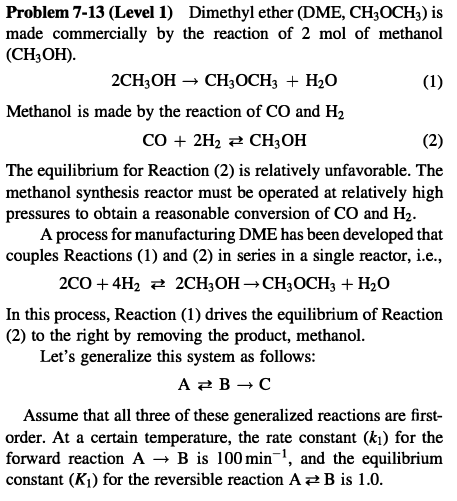

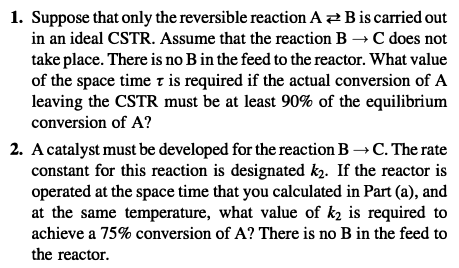


In [ ]:
# PROBLEMA 7-13 FOGLER
# INCISO 1
# Paso 1: Definimos nuestras variables y datos
Cao = 0.0001      # mol/L
k1 = 100          # min^-1
Kc = 1.0          # adimensional

# Paso 2: Definimos el sistema de ecuaciones no lineales
def sistema_inciso1(vars):
    Xeq, tau = vars

    # Conversión real requerida
    X = 0.9 * Xeq

    # Concentraciones de salida
    Ca = Cao * (1 - X)
    Cb = Cao * X

    # Velocidad de reacción de A
    Ra = -k1 * (Ca - Cb / Kc)

    # Ecuaciones
    eq1 = Xeq / (1 - Xeq) - Kc
    eq2 = Cao * X + Ra * tau

    return [eq1, eq2]

# Suposición inicial
guess1 = [0.1, 0.1]

# Paso 3: Resolver el sistema
sol1 = fsolve(sistema_inciso1, guess1)
Xeq, tau = sol1

# Cálculos adicionales
X1 = 0.9 * Xeq
Ca1 = Cao * (1 - X1)
Cb1 = Cao * X1
Ra1 = -k1 * (Ca1 - Cb1 / Kc)

# Paso 4: Tabla de resultados
tabla_inciso1 = pd.DataFrame({
    "Variable": ["Xeq", "X", "Ca", "Cb", "Ra", "tau"],
    "Valor": [Xeq, X1, Ca1, Cb1, Ra1, tau],
    "Unidad": ["adimensional", "adimensional", "mol/L", "mol/L", "mol/(L·min)", "min"]
})
display(Markdown("### Inciso 1: Determinación del tiempo espacial"))
tabla_inciso1["Valor"] = tabla_inciso1["Valor"].round(6)
display(tabla_inciso1.style.hide(axis="index"))

# INCISO 2
# Paso 1: Definimos nuestras variables y datos
Cbo = 0.0         # mol/L
Cco = 0.0         # mol/L
X_deseada = 0.75  # adimensional

# Paso 2: Definimos el sistema de ecuaciones no lineales
def sistema_inciso2(vars):
    Ca, Cb, Cc, Ra, Rb, Rc, k2 = vars

    # Balances molares en el CSTR
    eq1 = -Ca + Cao + Ra * tau
    eq2 = -Cb + Cbo + Rb * tau
    eq3 = -Cc + Cco + Rc * tau

    # Velocidades de reacción
    eq4 = -k1 * (Ca - Cb / Kc) - Ra
    eq5 = k1 * (Ca - Cb / Kc) - k2 * Cb - Rb
    eq6 = k2 * Cb - Rc

    # Conversión deseada
    eq7 = (Cao - Ca) / Cao - X_deseada

    return [eq1, eq2, eq3, eq4, eq5, eq6, eq7]

# Suposición inicial
guess2 = [2.5e-5, 1e-5, 6e-5, -0.001, 0.001, 0.001, 150]

# Paso 3: Resolver el sistema
sol2 = fsolve(sistema_inciso2, guess2)
Ca, Cb, Cc, Ra, Rb, Rc, k2 = sol2

# Conversión calculada
X2 = (Cao - Ca) / Cao

# Paso 4: Tabla de resultados
tabla_inciso2 = pd.DataFrame({
    "Variable": ["Ca", "Cb", "Cc", "Ra", "Rb", "Rc", "X", "k2"],
    "Valor": [Ca, Cb, Cc, Ra, Rb, Rc, X2, k2],
    "Unidad": ["mol/L", "mol/L", "mol/L", "mol/(L·min)", "mol/(L·min)", "mol/(L·min)", "adimensional", "min^-1"]
})
display(Markdown("### Inciso 2: Determinación de la constante de velocidad"))
tabla_inciso2["Valor"] = tabla_inciso2["Valor"].round(6)
display(tabla_inciso2.style.hide(axis="index"))

### Inciso 1: Determinación del tiempo espacial

Variable,Valor,Unidad
Xeq,0.500000,adimensional
X,0.450000,adimensional
Ca,0.000055,mol/L
Cb,0.000045,mol/L
Ra,-0.001000,mol/(L·min)
tau,0.045000,min


### Inciso 2: Determinación de la constante de velocidad

Variable,Valor,Unidad
Ca,0.000025,mol/L
Cb,0.000008,mol/L
Cc,0.000067,mol/L
Ra,-0.001667,mol/(L·min)
Rb,0.000185,mol/(L·min)
Rc,0.001481,mol/(L·min)
X,0.750000,adimensional
k2,177.777778,min^-1


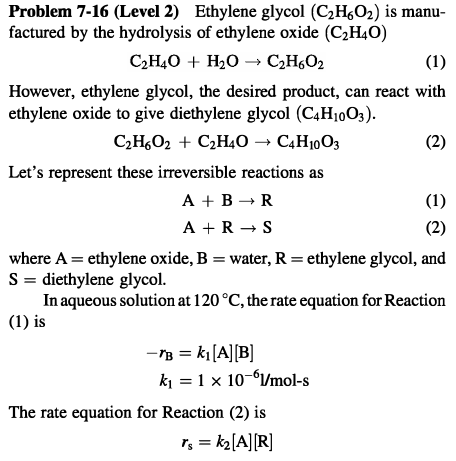

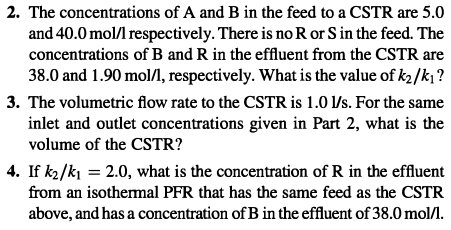

In [ ]:
# PROBLEMA 7-16 FOGLER
# INCISO 2: Determinación de la relación k2/k1 en un CSTR
display(Markdown("## Inciso 2: Determinación de la relación $k_2/k_1$ en un CSTR"))

# Paso 1: Definimos nuestras variables y datos
Cao = 5.0          # mol/L
Cbo = 40.0         # mol/L
Cro = 0.0          # mol/L
Cso = 0.0          # mol/L

Cb = 38.0          # mol/L  (salida dada)
Cr = 1.90          # mol/L  (salida dada)

k1 = 1e-6          # L/mol-s

# Paso 2: Definimos el sistema de ecuaciones no lineales
def sistema_inciso2(vars):
    Ca, tau, k2, Cs, Ra, Rb, Rr, Rs = vars

    eq1 = -Ca + Cao + Ra*tau
    eq2 = -Cb + Cbo + Rb*tau
    eq3 = -Cr + Cro + Rr*tau
    eq4 = -Cs + Cso + Rs*tau

    eq5 = -k1*Ca*Cb - k2*Ca*Cr - Ra
    eq6 = -k1*Ca*Cb - Rb
    eq7 =  k1*Ca*Cb - k2*Ca*Cr - Rr
    eq8 =  k2*Ca*Cr - Rs

    return [eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8]

# Suposición inicial
guess2 = [2.9, 1.8e4, 1e-6, 0.1, -1.2e-4, -1.1e-4, 7.0e-5, 1.5e-5]

# Paso 3: Resolver el sistema
sol2 = fsolve(sistema_inciso2, guess2)
Ca2, tau2, k2_2, Cs2, Ra2, Rb2, Rr2, Rs2 = sol2
relacion_k2_k1 = k2_2 / k1

# Paso 4: Tabla de resultados
tabla_inciso2 = pd.DataFrame({
    "Variable": ["Ca", "Cb", "Cr", "Cs", "Ra", "Rb", "Rr", "Rs", "tau", "k2", "k2/k1"],
    "Valor": [Ca2, Cb, Cr, Cs2, Ra2, Rb2, Rr2, Rs2, tau2, k2_2, relacion_k2_k1],
    "Unidad": ["mol/L", "mol/L", "mol/L", "mol/L",
               "mol/(L·s)", "mol/(L·s)", "mol/(L·s)", "mol/(L·s)",
               "s", "L/(mol·s)", "adimensional"]
})

tabla_inciso2["Valor"] = tabla_inciso2["Valor"].astype(float)
tabla_inciso2["Valor"] = tabla_inciso2["Valor"].map(lambda x: f"{x:.6g}")

display(tabla_inciso2.style.hide(axis="index"))

# INCISO 3: Determinación del volumen del CSTR
display(Markdown("## Inciso 3: Determinación del volumen del CSTR"))

# Paso 1: Definimos nuestras variables y datos
vo = 1.0           # L/s

# Paso 2: El volumen se obtiene de tau = V/vo
# Paso 3: Calculamos el volumen
V3 = tau2 * vo

# Paso 4: Tabla de resultados
tabla_inciso3 = pd.DataFrame({
    "Variable": ["tau", "vo", "V"],
    "Valor": [tau2, vo, V3],
    "Unidad": ["s", "L/s", "L"]
})

tabla_inciso3["Valor"] = tabla_inciso3["Valor"].astype(float)
tabla_inciso3["Valor"] = tabla_inciso3["Valor"].map(lambda x: f"{x:.6g}")

display(tabla_inciso3.style.hide(axis="index"))

# INCISO 4: Cálculo de la concentración de R en un PFR
# ajustando el volumen para que Cb = 38.0 mol/L

display(Markdown("## Inciso 4: Determinación de la concentración de $R$ en el efluente de un PFR"))

# Paso 1: Definimos nuestras variables y datos
k2_4 = 2.0 * k1    # porque k2/k1 = 2.0
vo4 = 1.0          # L/s

Fa0 = 5.0          # mol/s
Fb0 = 40.0         # mol/s
Fr0 = 0.0          # mol/s
Fs0 = 0.0          # mol/s

# Paso 2: Definimos el sistema de ecuaciones diferenciales
def sistema_pfr(V, F):
    Fa, Fb, Fr, Fs = F

    Ca = Fa / vo4
    Cb_local = Fb / vo4
    Cr_local = Fr / vo4

    Ra = -k1*Ca*Cb_local - k2_4*Ca*Cr_local
    Rb = -k1*Ca*Cb_local
    Rr =  k1*Ca*Cb_local - k2_4*Ca*Cr_local
    Rs =  k2_4*Ca*Cr_local

    return [Ra, Rb, Rr, Rs]

# Evento para detener la integración cuando Cb = 38 mol/L
def evento_cb_38(V, F):
    Fa, Fb, Fr, Fs = F
    Cb_local = Fb / vo4
    return Cb_local - 38.0

evento_cb_38.terminal = True
evento_cb_38.direction = -1

# Paso 3: Resolver el sistema diferencial
F0 = [Fa0, Fb0, Fr0, Fs0]

sol4 = solve_ivp(
    sistema_pfr,
    t_span=(0, 5e4),         # rango amplio de volumen para encontrar el evento
    y0=F0,
    events=evento_cb_38,
    dense_output=True,
    max_step=100
)

# Extraemos el punto donde Cb = 38
V4 = sol4.t_events[0][0]
Fa4, Fb4, Fr4, Fs4 = sol4.y_events[0][0]

Ca4 = Fa4 / vo4
Cb4 = Fb4 / vo4
Cr4 = Fr4 / vo4
Cs4 = Fs4 / vo4

Ra4 = -k1*Ca4*Cb4 - k2_4*Ca4*Cr4
Rb4 = -k1*Ca4*Cb4
Rr4 =  k1*Ca4*Cb4 - k2_4*Ca4*Cr4
Rs4 =  k2_4*Ca4*Cr4

# Paso 4: Tabla de resultados
tabla_inciso4 = pd.DataFrame({
    "Variable": ["V", "Ca", "Cb", "Cr", "Cs", "Fa", "Fb", "Fr", "Fs", "Ra", "Rb", "Rr", "Rs"],
    "Valor": [V4, Ca4, Cb4, Cr4, Cs4, Fa4, Fb4, Fr4, Fs4, Ra4, Rb4, Rr4, Rs4],
    "Unidad": ["L", "mol/L", "mol/L", "mol/L", "mol/L",
               "mol/s", "mol/s", "mol/s", "mol/s",
               "mol/(L·s)", "mol/(L·s)", "mol/(L·s)", "mol/(L·s)"]
})

tabla_inciso4["Valor"] = tabla_inciso4["Valor"].astype(float)
tabla_inciso4["Valor"] = tabla_inciso4["Valor"].map(lambda x: f"{x:.6g}")

display(tabla_inciso4.style.hide(axis="index"))

## Inciso 2: Determinación de la relación $k_2/k_1$ en un CSTR

Variable,Valor,Unidad
Ca,2.9,mol/L
Cb,38,mol/L
Cr,1.9,mol/L
Cs,0.1,mol/L
Ra,-0.00011571,mol/(L·s)
Rb,-0.0001102,mol/(L·s)
Rr,0.00010469,mol/(L·s)
Rs,5.51e-06,mol/(L·s)
tau,18148.8,s
k2,1e-06,L/(mol·s)


## Inciso 3: Determinación del volumen del CSTR

Variable,Valor,Unidad
tau,18148.8,s
vo,1,L/s
V,18148.8,L


## Inciso 4: Determinación de la concentración de $R$ en el efluente de un PFR

Variable,Valor,Unidad
V,13279,L
Ca,2.9,mol/L
Cb,38,mol/L
Cr,1.9,mol/L
Cs,0.1,mol/L
Fa,2.9,mol/s
Fb,38,mol/s
Fr,1.9,mol/s
Fs,0.1,mol/s
Ra,-0.00012122,mol/(L·s)
